# Sales Data Analysis

## Project Overview

This project analyzes sales data to identify revenue trends, customer behavior, product category performance, regional sales performance, payment preferences, and delivery patterns.

## Objectives

- Analyze overall sales and revenue performance
- Identify the highest revenue product category
- Compare revenue across different regions
- Analyze popular payment methods
- Identify monthly revenue trends
- Analyze customer ratings
- Evaluate delivery performance by region
- Compare quantity sold across product categories

## Tools & Technologies

- Python
- Pandas
- Matplotlib
- Jupyter Notebook
- VS Code
- GitHub

In [2]:
import pandas as pd

df = pd.read_csv("../data/ecommerce_sales_analytics_5000.csv")

df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [1]:
df.shape

NameError: name 'df' is not defined

In [2]:
df.shape

NameError: name 'df' is not defined

In [4]:
df.shape

(5000, 12)

In [5]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='str')

# Data Analysis

## 1. Loading and Understanding the Dataset

The dataset was loaded using Pandas and analyzed to understand its structure, columns, data types, and overall contents.

In [6]:
df.info

<bound method DataFrame.info of       order_id order_date  customer_id product_category region  quantity  \
0        10001   1/1/2022         1102           Beauty  South         7   
1        10002   1/2/2022         1435         Clothing  South         7   
2        10003   1/3/2022         1860           Beauty   East         3   
3        10004   1/4/2022         1270      Electronics   West         5   
4        10005   1/5/2022         1106         Clothing   West         5   
...        ...        ...          ...              ...    ...       ...   
4995     14996   9/5/2035         1289         Clothing   West         2   
4996     14997   9/6/2035         1294           Beauty  North         3   
4997     14998   9/7/2035         1450           Beauty   West         3   
4998     14999   9/8/2035         1903      Electronics  South         4   
4999     15000   9/9/2035         1214             Home   East         7   

      unit_price  discount payment_method  delivery_day

In [7]:
df.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
std,1443.520003,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000


In [8]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

order_id              int64
order_date              str
customer_id           int64
product_category        str
region                  str
quantity              int64
unit_price          float64
discount            float64
payment_method          str
delivery_days         int64
customer_rating     float64
revenue             float64
dtype: object

## 2. Data Cleaning

The dataset was checked for data consistency and the `order_date` column was converted into a proper datetime format. This allows us to perform time-based analysis such as monthly revenue analysis.

In [10]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [12]:
df.dtypes

order_id                     int64
order_date          datetime64[us]
customer_id                  int64
product_category               str
region                         str
quantity                     int64
unit_price                 float64
discount                   float64
payment_method                 str
delivery_days                int64
customer_rating            float64
revenue                    float64
dtype: object

# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand sales performance, customer behavior, product categories, regional performance, payment methods, and other important business metrics.

### 3.1 Overall Sales Performance

The overall sales performance was analyzed by calculating total revenue, total orders, and total quantity sold.

In [13]:
total_revenue = df["revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 5109775.74


In [14]:
df["revenue"]

0       1883.20
1        304.10
2        644.35
3       2569.90
4        468.56
         ...   
4995     542.74
4996    1428.47
4997     176.06
4998     437.38
4999    1069.90
Name: revenue, Length: 5000, dtype: float64

In [15]:
.sum()

SyntaxError: invalid syntax (112788159.py, line 1)

In [16]:
sum()

TypeError: sum() takes at least 1 positional argument (0 given)

In [17]:
total_revenue = df["revenue"].sum()

print("Total Revenue:", round(total_revenue, 2))

Total Revenue: 5109775.74


In [18]:
total_revenue

np.float64(5109775.74)

In [19]:
total_orders = df["order_id"].nunique()

print("Total Orders:", total_orders)

Total Orders: 5000


In [20]:
total_quantity = df["quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 20224


In [21]:
average_order_value = total_revenue / total_orders

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 1021.96


In [22]:
average_rating = df["customer_rating"].mean()

print("Average Customer Rating:", round(average_rating, 2))

Average Customer Rating: 2.97


In [23]:
average_delivery = df["delivery_days"].mean()

print("Average Delivery Time:", round(average_delivery, 2), "days")

Average Delivery Time: 6.12 days


In [24]:
print("========== E-COMMERCE SALES SUMMARY ==========")
print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Quantity Sold:", total_quantity)
print("Average Order Value:", round(average_order_value, 2))
print("Average Customer Rating:", round(average_rating, 2))
print("Average Delivery Time:", round(average_delivery, 2), "days")

========== E-COMMERCE SALES SUMMARY ==========
Total Revenue: 5109775.74
Total Orders: 5000
Total Quantity Sold: 20224
Average Order Value: 1021.96
Average Customer Rating: 2.97
Average Delivery Time: 6.12 days


## Product Category Analysis

This section analyzes revenue performance across different product categories to identify the categories generating the highest revenue.

In [25]:
category_revenue = df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)

category_revenue

product_category
Electronics    1829899.22
Clothing       1531931.72
Home            982083.92
Beauty          765860.88
Name: revenue, dtype: float64

In [26]:
groupby("product_category")

NameError: name 'groupby' is not defined

In [27]:
top_category = category_revenue.idxmax()
top_category_revenue = category_revenue.max()

print("Top Revenue Category:", top_category)
print("Revenue:", round(top_category_revenue, 2))

Top Revenue Category: Electronics
Revenue: 1829899.22


In [28]:
df.groupby("product_category")

In [29]:
df.groupby("product_category")["revenue"]

In [30]:
df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)

product_category
Electronics    1829899.22
Clothing       1531931.72
Home            982083.92
Beauty          765860.88
Name: revenue, dtype: float64

In [31]:
["revenue"].sum()

AttributeError: 'list' object has no attribute 'sum'

In [32]:
sort_values(ascending=False)

NameError: name 'sort_values' is not defined

## Regional Sales Analysis

This section analyzes revenue performance across different geographical regions.

In [33]:
region_revenue = df.groupby("region")["revenue"].sum().sort_values(ascending=False)

region_revenue

region
West     1345582.16
North    1281508.45
South    1246640.90
East     1236044.23
Name: revenue, dtype: float64

In [34]:
top_region = region_revenue.idxmax()
top_region_revenue = region_revenue.max()

print("Top Revenue Region:", top_region)
print("Revenue:", round(top_region_revenue, 2))

Top Revenue Region: West
Revenue: 1345582.16


### 3.3 Payment Method Analysis

The payment methods used by customers were analyzed to identify the most popular payment method and understand customer payment preferences.

In [35]:
payment_counts = df["payment_method"].value_counts()

payment_counts

payment_method
Card      2270
COD       1774
Wallet     956
Name: count, dtype: int64

In [36]:
most_used_payment = payment_counts.idxmax()

print("Most Used Payment Method:", most_used_payment)

Most Used Payment Method: Card


In [37]:
payment_revenue = df.groupby("payment_method")["revenue"].sum().sort_values(ascending=False)

payment_revenue

payment_method
Card      2366248.20
COD       1788408.44
Wallet     955119.10
Name: revenue, dtype: float64

In [38]:
category_revenue

product_category
Electronics    1829899.22
Clothing       1531931.72
Home            982083.92
Beauty          765860.88
Name: revenue, dtype: float64

In [39]:
region_revenue

region
West     1345582.16
North    1281508.45
South    1246640.90
East     1236044.23
Name: revenue, dtype: float64

In [40]:
payment_counts

payment_method
Card      2270
COD       1774
Wallet     956
Name: count, dtype: int64

In [41]:
payment_revenue = df.groupby("payment_method")["revenue"].sum().sort_values(ascending=False)

payment_revenue

payment_method
Card      2366248.20
COD       1788408.44
Wallet     955119.10
Name: revenue, dtype: float64

In [42]:
top_payment_revenue = payment_revenue.idxmax()
top_payment_revenue_value = payment_revenue.max()

print("Highest Revenue Payment Method:", top_payment_revenue)
print("Revenue:", round(top_payment_revenue_value, 2))

Highest Revenue Payment Method: Card
Revenue: 2366248.2


In [43]:
category_quantity = df.groupby("product_category")["quantity"].sum().sort_values(ascending=False)

category_quantity

product_category
Electronics    7109
Clothing       6171
Home           3949
Beauty         2995
Name: quantity, dtype: int64

In [44]:
top_quantity_category = category_quantity.idxmax()
top_quantity = category_quantity.max()

print("Highest Quantity Category:", top_quantity_category)
print("Quantity Sold:", top_quantity)

Highest Quantity Category: Electronics
Quantity Sold: 7109


### 3.5 Customer Rating Analysis

Customer ratings were analyzed across product categories to understand customer satisfaction and identify categories with higher average ratings.

In [45]:
category_rating = df.groupby("product_category")["customer_rating"].mean().sort_values(ascending=False)

category_rating

product_category
Beauty         3.008990
Clothing       3.005095
Electronics    2.951097
Home           2.940660
Name: customer_rating, dtype: float64

In [46]:
top_rated_category = category_rating.idxmax()
top_rating = category_rating.max()

print("Highest Rated Category:", top_rated_category)
print("Average Rating:", round(top_rating, 2))

Highest Rated Category: Beauty
Average Rating: 3.01


In [47]:
region_delivery = df.groupby("region")["delivery_days"].mean().sort_values()

region_delivery

region
West     6.082234
East     6.104319
North    6.118339
South    6.173013
Name: delivery_days, dtype: float64

In [48]:
fastest_region = region_delivery.idxmin()
fastest_delivery = region_delivery.min()

slowest_region = region_delivery.idxmax()
slowest_delivery = region_delivery.max()

print("Fastest Delivery Region:", fastest_region)
print("Average Delivery Time:", round(fastest_delivery, 2), "days")

print("Slowest Delivery Region:", slowest_region)
print("Average Delivery Time:", round(slowest_delivery, 2), "days")

Fastest Delivery Region: West
Average Delivery Time: 6.08 days
Slowest Delivery Region: South
Average Delivery Time: 6.17 days


# 4. Data Visualization

This section presents visualizations to identify sales trends, product performance, regional performance, payment preferences, and customer behavior.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

In [3]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Seaborn is working!")

Seaborn is working!


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

## Revenue by Product Category

This visualization compares the total revenue generated by each product category.

In [6]:
plt.figure(figsize=(8, 5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

NameError: name 'category_revenue' is not defined

<Figure size 800x500 with 0 Axes>

In [11]:
category_revenue = df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)

category_revenue

product_category
Electronics    1829899.22
Clothing       1531931.72
Home            982083.92
Beauty          765860.88
Name: revenue, dtype: float64

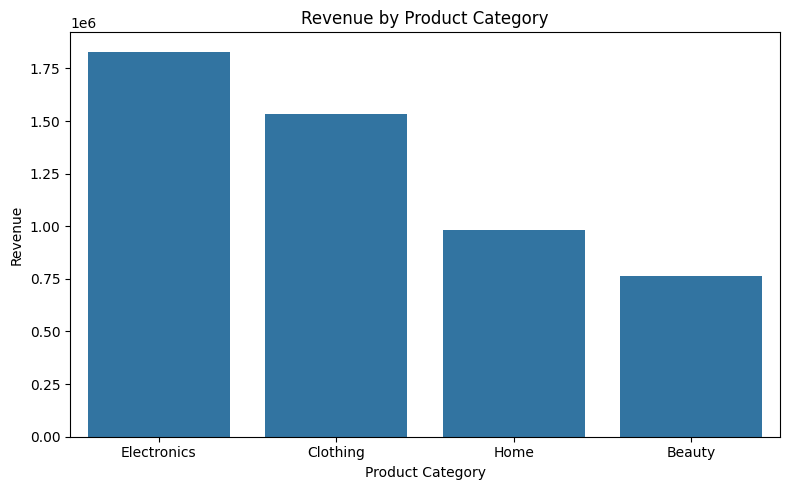

In [12]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

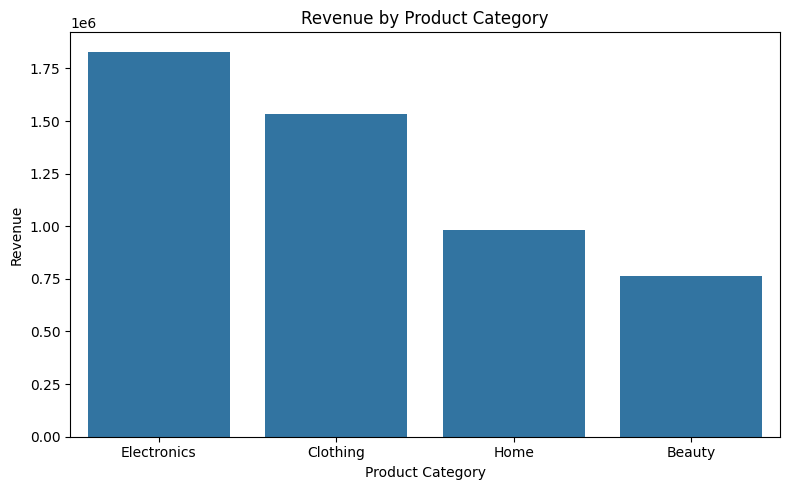

In [13]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Revenue by Region

This visualization compares revenue performance across different regions.

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_revenue.index,
    y=region_revenue.values
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

NameError: name 'region_revenue' is not defined

<Figure size 800x500 with 0 Axes>

In [5]:
region_revenue = df.groupby("region")["revenue"].sum().sort_values(ascending=False)

region_revenue

region
West     1345582.16
North    1281508.45
South    1246640.90
East     1236044.23
Name: revenue, dtype: float64

In [6]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_revenue.index,
    y=region_revenue.values
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


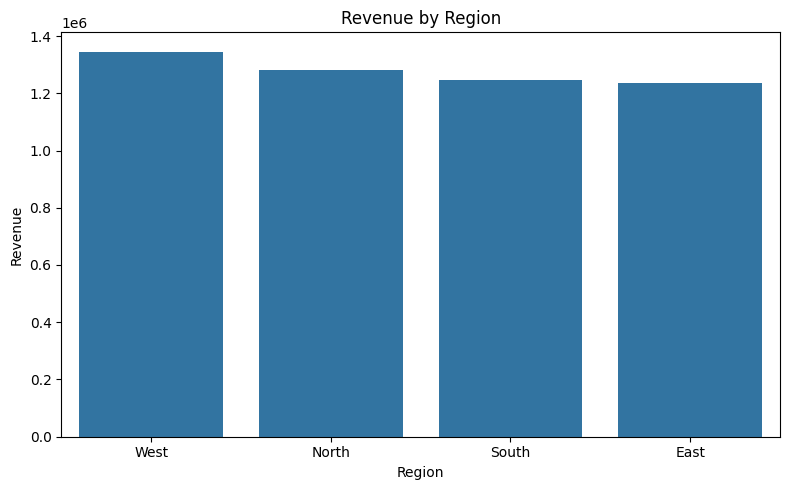

In [8]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=region_revenue.index,
    y=region_revenue.values
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Payment Method Usage

This visualization shows the number of orders made using each payment method.

In [9]:
payment_counts = df["payment_method"].value_counts()

payment_counts

payment_method
Card      2270
COD       1774
Wallet     956
Name: count, dtype: int64

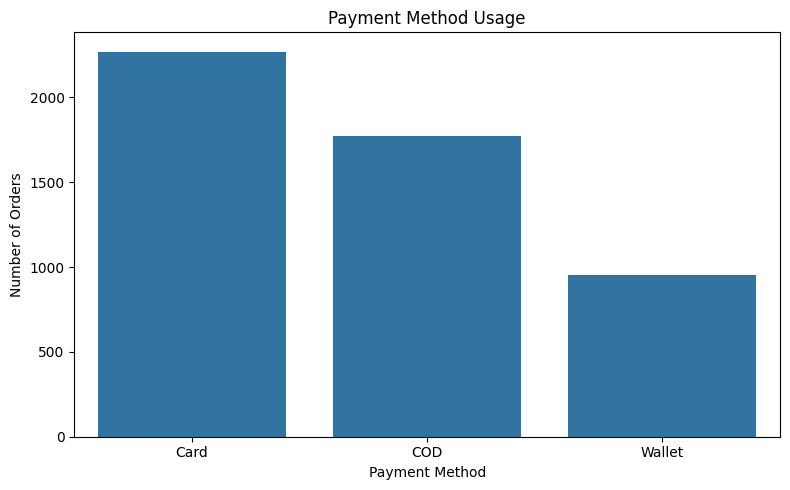

In [10]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

## Revenue by Payment Method

This visualization compares the total revenue generated through different payment methods.

In [11]:
payment_revenue = df.groupby("payment_method")["revenue"].sum().sort_values(ascending=False)

payment_revenue

payment_method
Card      2366248.20
COD       1788408.44
Wallet     955119.10
Name: revenue, dtype: float64

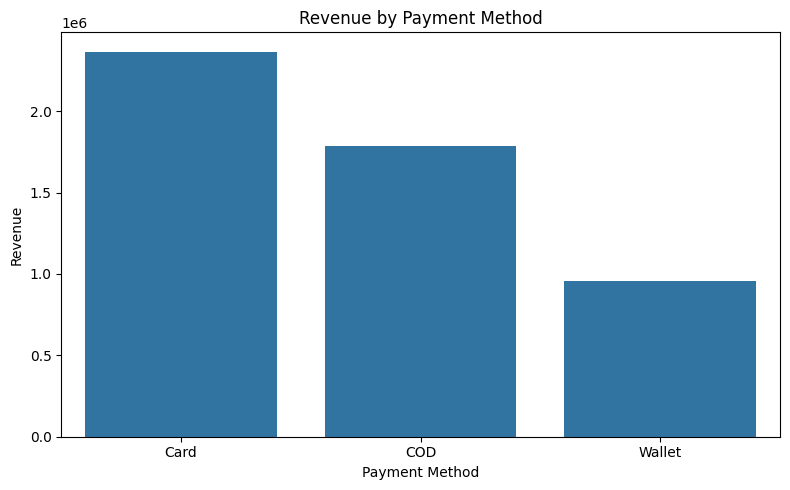

In [12]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=payment_revenue.index,
    y=payment_revenue.values
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

## Quantity Sold by Product Category

This visualization compares the total quantity of products sold across different product categories.

In [13]:
category_quantity = df.groupby("product_category")["quantity"].sum().sort_values(ascending=False)

category_quantity

product_category
Electronics    7109
Clothing       6171
Home           3949
Beauty         2995
Name: quantity, dtype: int64

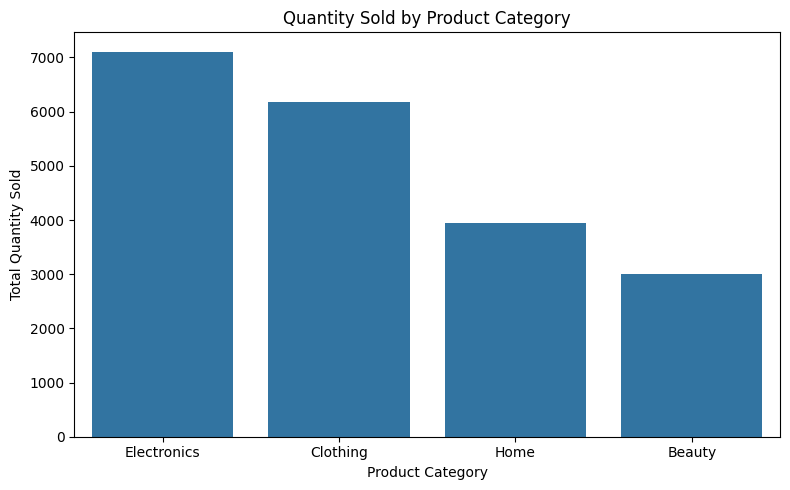

In [14]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_quantity.index,
    y=category_quantity.values
)

plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [15]:
product_revenue = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

print(product_revenue.head(10))

KeyError: 'Product'

In [16]:
print(df.columns)

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='str')


In [17]:
print(df.columns.tolist())

['order_id', 'order_date', 'customer_id', 'product_category', 'region', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'customer_rating', 'revenue']


In [18]:
category_revenue = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

print(category_revenue)

product_category
Electronics    1829899.22
Clothing       1531931.72
Home            982083.92
Beauty          765860.88
Name: revenue, dtype: float64


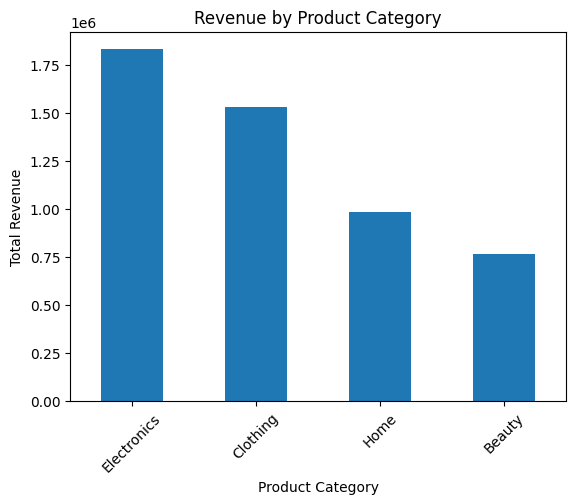

In [19]:
category_revenue.plot(kind='bar', title='Revenue by Product Category')

plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

In [3]:
region_revenue = df.groupby('region')['revenue'].sum().sort_values(ascending=False)

print(region_revenue)

region
West     1345582.16
North    1281508.45
South    1246640.90
East     1236044.23
Name: revenue, dtype: float64


NameError: name 'plt' is not defined

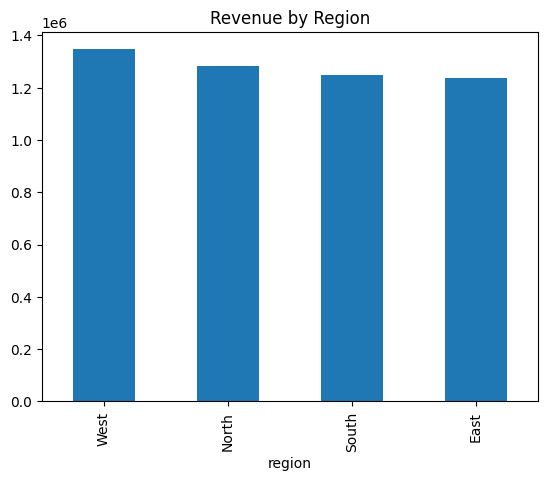

In [4]:
region_revenue.plot(kind='bar', title='Revenue by Region')

plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

In [5]:
payment_counts = df['payment_method'].value_counts()

print(payment_counts)

payment_method
Card      2270
COD       1774
Wallet     956
Name: count, dtype: int64


NameError: name 'plt' is not defined

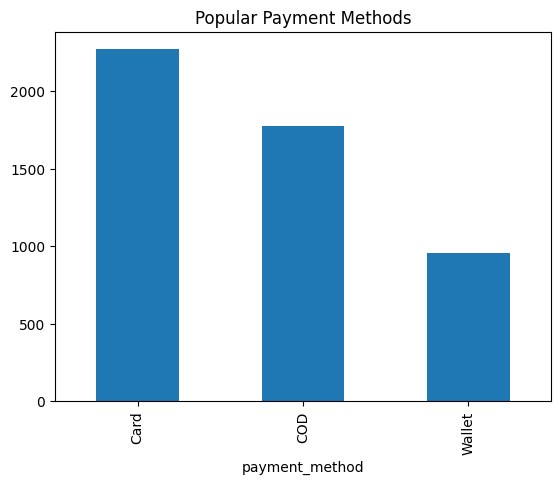

In [6]:
payment_counts.plot(kind='bar', title='Popular Payment Methods')

plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

In [7]:
df['order_date'] = pd.to_datetime(df['order_date'])

df['month'] = df['order_date'].dt.to_period('M').astype(str)

print(df[['order_date', 'month']].head())

  order_date    month
0 2022-01-01  2022-01
1 2022-01-02  2022-01
2 2022-01-03  2022-01
3 2022-01-04  2022-01
4 2022-01-05  2022-01


### 3.4 Monthly Revenue Analysis

Monthly revenue was analyzed to identify revenue trends over time and determine periods with higher or lower sales.

In [8]:
monthly_revenue = df.groupby('month')['revenue'].sum()

print(monthly_revenue)

month
2022-01    35624.89
2022-02    29908.89
2022-03    30309.28
2022-04    30781.96
2022-05    41629.24
             ...   
2035-05    33393.87
2035-06    25205.26
2035-07    23944.48
2035-08    29354.74
2035-09     4952.23
Name: revenue, Length: 165, dtype: float64


NameError: name 'plt' is not defined

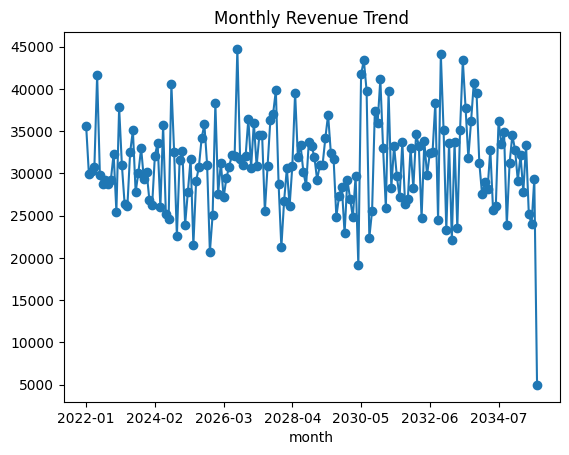

In [10]:
monthly_revenue.plot(kind='line', marker='o', title='Monthly Revenue Trend')

plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [11]:
import matplotlib.pyplot as plt

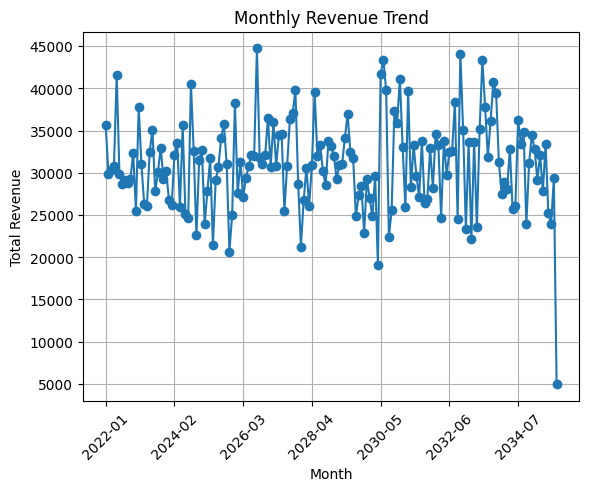

In [12]:
monthly_revenue.plot(kind='line', marker='o', title='Monthly Revenue Trend')

plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [13]:
category_rating = df.groupby('product_category')['customer_rating'].mean().sort_values(ascending=False)

print(category_rating)

product_category
Beauty         3.008990
Clothing       3.005095
Electronics    2.951097
Home           2.940660
Name: customer_rating, dtype: float64


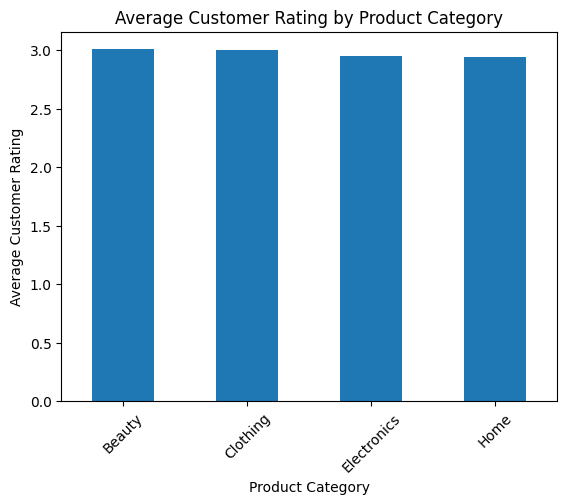

In [14]:
category_rating.plot(kind='bar', title='Average Customer Rating by Product Category')

plt.xlabel('Product Category')
plt.ylabel('Average Customer Rating')
plt.xticks(rotation=45)
plt.show()

### 3.6 Delivery Time Analysis

Average delivery time was analyzed across different regions to identify variations in delivery performance.

In [15]:
delivery_region = df.groupby('region')['delivery_days'].mean().sort_values(ascending=False)

print(delivery_region)

region
South    6.173013
North    6.118339
East     6.104319
West     6.082234
Name: delivery_days, dtype: float64


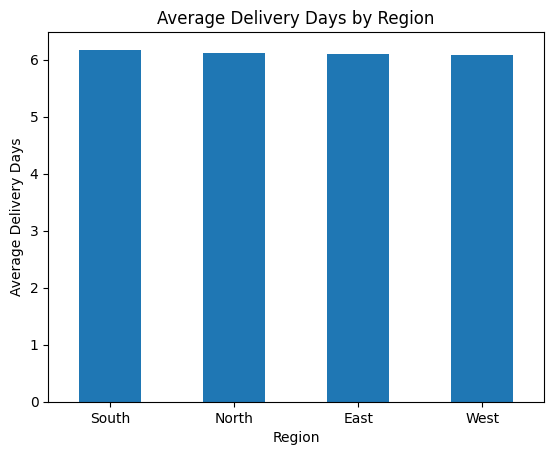

In [16]:
delivery_region.plot(kind='bar', title='Average Delivery Days by Region')

plt.xlabel('Region')
plt.ylabel('Average Delivery Days')
plt.xticks(rotation=0)
plt.show()

### 3.7 Quantity Sold by Product Category

The total quantity sold was analyzed across product categories to identify which categories had the highest sales volume.

In [17]:
category_quantity = df.groupby('product_category')['quantity'].sum().sort_values(ascending=False)

print(category_quantity)

product_category
Electronics    7109
Clothing       6171
Home           3949
Beauty         2995
Name: quantity, dtype: int64


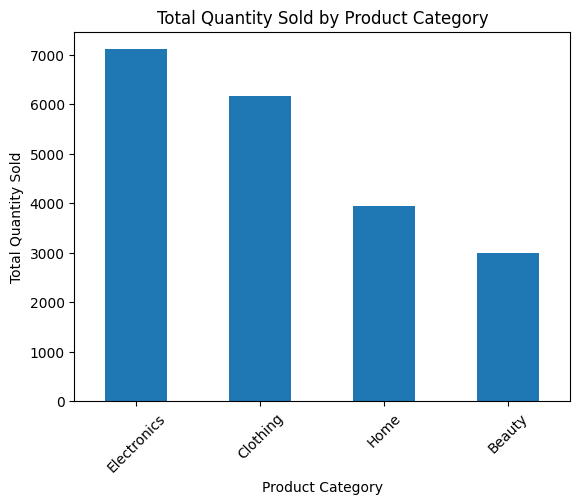

In [18]:
category_quantity.plot(kind='bar', title='Total Quantity Sold by Product Category')

plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.show()

In [19]:
print("===== FINAL ANALYSIS SUMMARY =====")

# Total Revenue
print("Total Revenue:", df['revenue'].sum())

# Total Orders
print("Total Orders:", df['order_id'].nunique())

# Total Quantity Sold
print("Total Quantity Sold:", df['quantity'].sum())

# Average Customer Rating
print("Average Customer Rating:", round(df['customer_rating'].mean(), 2))

# Average Delivery Time
print("Average Delivery Days:", round(df['delivery_days'].mean(), 2))

# Highest Revenue Category
print("Highest Revenue Category:", category_revenue.idxmax())

# Highest Revenue Region
print("Highest Revenue Region:", region_revenue.idxmax())

# Most Popular Payment Method
print("Most Popular Payment Method:", payment_counts.idxmax())

# Highest Rated Category
print("Highest Rated Category:", category_rating.idxmax())

# Longest Delivery Region
print("Longest Delivery Region:", delivery_region.idxmax())

# Highest Quantity Category
print("Highest Quantity Category:", category_quantity.idxmax())

===== FINAL ANALYSIS SUMMARY =====
Total Revenue: 5109775.74
Total Orders: 5000
Total Quantity Sold: 20224
Average Customer Rating: 2.97
Average Delivery Days: 6.12


NameError: name 'category_revenue' is not defined

## 4. Final Analysis Summary

The analysis provides insights into overall sales performance, product category performance, regional revenue, customer payment preferences, customer ratings, delivery performance, and sales volume.

In [20]:
print("===== FINAL ANALYSIS SUMMARY =====")

# Basic Summary
print("Total Revenue:", df['revenue'].sum())
print("Total Orders:", df['order_id'].nunique())
print("Total Quantity Sold:", df['quantity'].sum())
print("Average Customer Rating:", round(df['customer_rating'].mean(), 2))
print("Average Delivery Days:", round(df['delivery_days'].mean(), 2))

# Highest Revenue Category
category_revenue = df.groupby('product_category')['revenue'].sum()
print("Highest Revenue Category:", category_revenue.idxmax())

# Highest Revenue Region
region_revenue = df.groupby('region')['revenue'].sum()
print("Highest Revenue Region:", region_revenue.idxmax())

# Most Popular Payment Method
payment_counts = df['payment_method'].value_counts()
print("Most Popular Payment Method:", payment_counts.idxmax())

# Highest Rated Category
category_rating = df.groupby('product_category')['customer_rating'].mean()
print("Highest Rated Category:", category_rating.idxmax())

# Longest Delivery Region
delivery_region = df.groupby('region')['delivery_days'].mean()
print("Longest Delivery Region:", delivery_region.idxmax())

# Highest Quantity Category
category_quantity = df.groupby('product_category')['quantity'].sum()
print("Highest Quantity Category:", category_quantity.idxmax())

===== FINAL ANALYSIS SUMMARY =====
Total Revenue: 5109775.74
Total Orders: 5000
Total Quantity Sold: 20224
Average Customer Rating: 2.97
Average Delivery Days: 6.12
Highest Revenue Category: Electronics
Highest Revenue Region: West
Most Popular Payment Method: Card
Highest Rated Category: Beauty
Longest Delivery Region: South
Highest Quantity Category: Electronics


### 3.8 Revenue by Payment Method

Revenue was analyzed across different payment methods to identify which payment method contributed the highest total revenue.

In [21]:
payment_revenue = df.groupby('payment_method')['revenue'].sum().sort_values(ascending=False)

print(payment_revenue)

payment_method
Card      2366248.20
COD       1788408.44
Wallet     955119.10
Name: revenue, dtype: float64


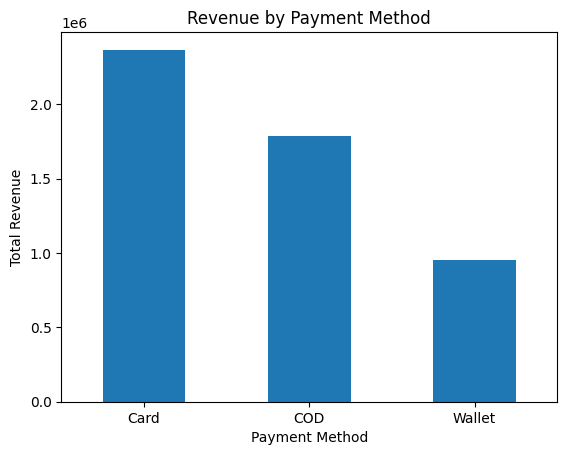

In [22]:
payment_revenue.plot(kind='bar', title='Revenue by Payment Method')

plt.xlabel('Payment Method')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()